# CSE 220: Signals and Linear Systems — Predicted Lab Solutions
Task functions and visualizations for all six question sets.

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

INF = 8
N = np.arange(-INF, INF + 1)   # index axis -8..8

x = np.array([0,0,0,0,0,0,0.5,2,1,0.5,1,0,0,0,0,0,0])

def stem_plot(ax, n, y, title):
    ax.stem(n, y, basefmt=" ")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("n")
    ax.grid(alpha=0.3)


## Question Set 1 — Time Shift and Time Scaling

In [1]:
def time_shift_signal(x, k):
    """y[n] = x[n-k]. Positive k delays (shifts right)."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    if k >= 0:
        if k < len(x):
            y[k:] = x[:len(x) - k]
    else:
        k = -k
        if k < len(x):
            y[:len(x) - k] = x[k:]
    return y

def time_scale_signal(x, k):
    """y[n] = x[k*n], k positive integer (compression)."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    valid = (k * N >= -INF) & (k * N <= INF)
    idx_out = N[valid] + INF
    idx_in = (k * N[valid]) + INF
    y[idx_out] = x[idx_in]
    return y


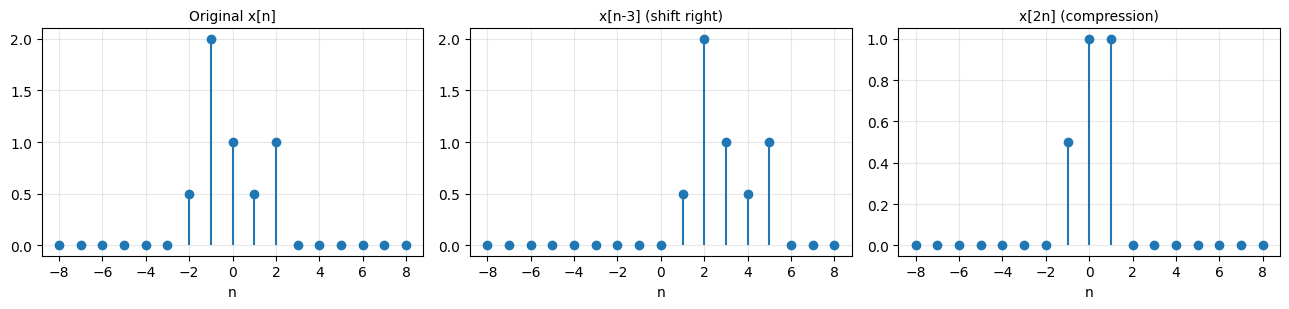

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
stem_plot(axs[0], N, x, "Original x[n]")
stem_plot(axs[1], N, time_shift_signal(x, 3), "x[n-3] (shift right)")
stem_plot(axs[2], N, time_scale_signal(x, 2), "x[2n] (compression)")
plt.tight_layout()
plt.show()


## Question Set 2 — Time Reversal and Even–Odd Decomposition

In [4]:
def time_reverse_signal(x):
    """y[n] = x[-n]"""
    x = np.asarray(x, dtype=float)
    return x[::-1]

def odd_even_decomposition(x):
    """Return (odd, even) components."""
    x = np.asarray(x, dtype=float)
    x_rev = time_reverse_signal(x)
    even = 0.5 * (x + x_rev)
    odd = 0.5 * (x - x_rev)
    return odd, even


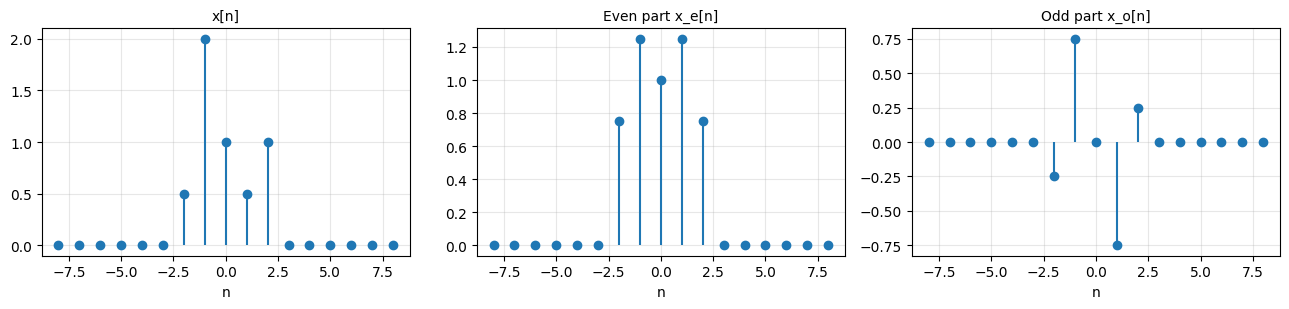

In [5]:
odd, even = odd_even_decomposition(x)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
stem_plot(axs[0], N, x, "x[n]")
stem_plot(axs[1], N, even, "Even part x_e[n]")
stem_plot(axs[2], N, odd, "Odd part x_o[n]")
plt.tight_layout()
plt.show()


## Question Set 3 — Time Scaling with Interpolation

In [6]:
def time_scale_expand(x, k):
    """y[n] = x[n/k], k positive integer (up-scaling / expansion), zeros elsewhere."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    ratio = N / k
    is_int = np.isclose(ratio, np.round(ratio))
    valid = is_int & (ratio >= -INF) & (ratio <= INF)
    src_idx = np.round(ratio[valid]).astype(int) + INF
    dst_idx = N[valid] + INF
    y[dst_idx] = x[src_idx]
    return y

def time_scale_interpolate(x, k):
    """Same as above, but non-integer n/k positions get the average of floor/ceil neighbors."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    ratio = N / k

    lo = np.floor(ratio).astype(int)
    hi = np.ceil(ratio).astype(int)

    in_range = (lo >= -INF) & (hi <= INF)

    lo_idx = lo[in_range] + INF
    hi_idx = hi[in_range] + INF
    dst_idx = N[in_range] + INF

    y[dst_idx] = 0.5 * (x[lo_idx] + x[hi_idx])
    return y


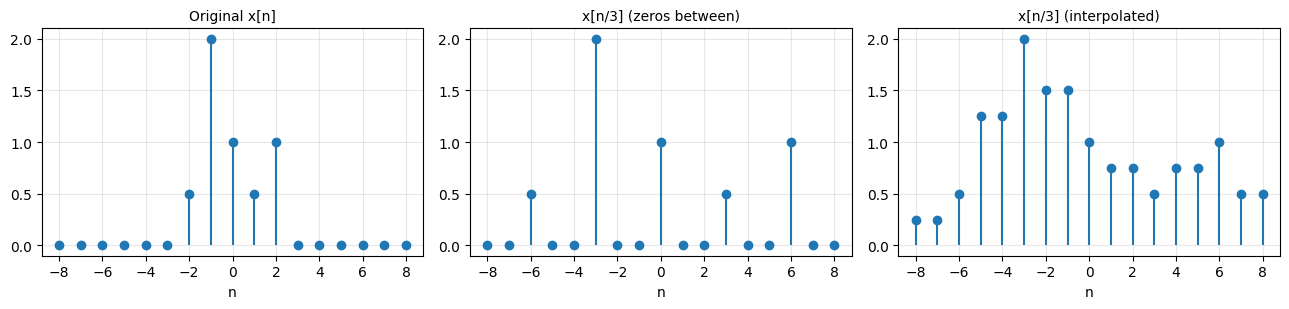

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
stem_plot(axs[0], N, x, "Original x[n]")
stem_plot(axs[1], N, time_scale_expand(x, 3), "x[n/3] (zeros between)")
stem_plot(axs[2], N, time_scale_interpolate(x, 3), "x[n/3] (interpolated)")
plt.tight_layout()
plt.show()


## Question Set 4 — Combined Transformation x[αn + β]

In [8]:
def transform(x, alpha, beta):
    """y[n] = x[alpha*n + beta], alpha nonzero integer, beta integer."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    arg = alpha * N + beta
    valid = (arg >= -INF) & (arg <= INF)
    y[N[valid] + INF] = x[arg[valid] + INF]
    return y


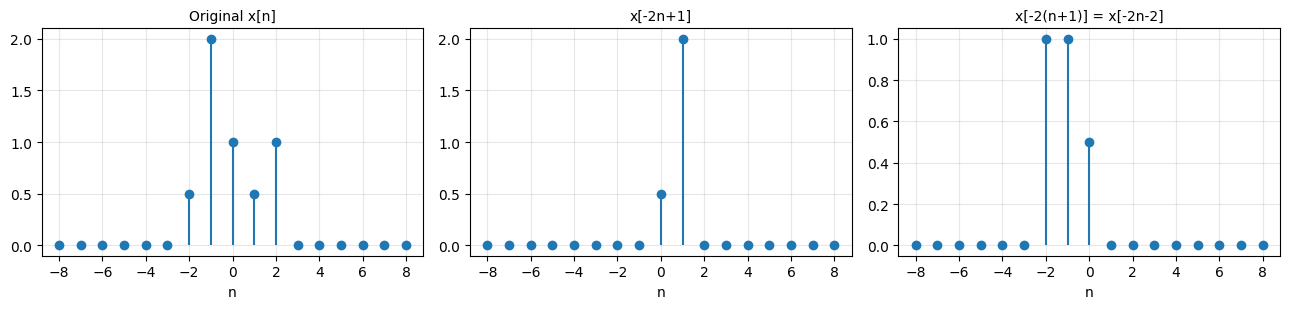

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
stem_plot(axs[0], N, x, "Original x[n]")
stem_plot(axs[1], N, transform(x, -2, 1), "x[-2n+1]")
stem_plot(axs[2], N, transform(x, -2, -2), "x[-2(n+1)] = x[-2n-2]")
plt.tight_layout()
plt.show()


## Question Set 5 — Phase Shift vs. Time Shift in a Sinusoid

In [10]:
def sinusoid(n, A, Omega0, phi):
    """x[n] = A*cos(Omega0*n + phi)"""
    n = np.asarray(n, dtype=float)
    return A * np.cos(Omega0 * n + phi)

def time_shift_sinusoid(n, A, Omega0, phi, n0):
    """x[n - n0]"""
    n = np.asarray(n, dtype=float)
    return A * np.cos(Omega0 * (n - n0) + phi)

def phase_change_sinusoid(n, A, Omega0, phi, phi0):
    """
    A*cos(Omega0*n + phi + phi0).
    Note: right time-shift by n0 <=> phase change of phi0 = -Omega0*n0
    (since x[n-n0] = A*cos(Omega0*n - Omega0*n0 + phi)).
    """
    n = np.asarray(n, dtype=float)
    return A * np.cos(Omega0 * n + phi + phi0)


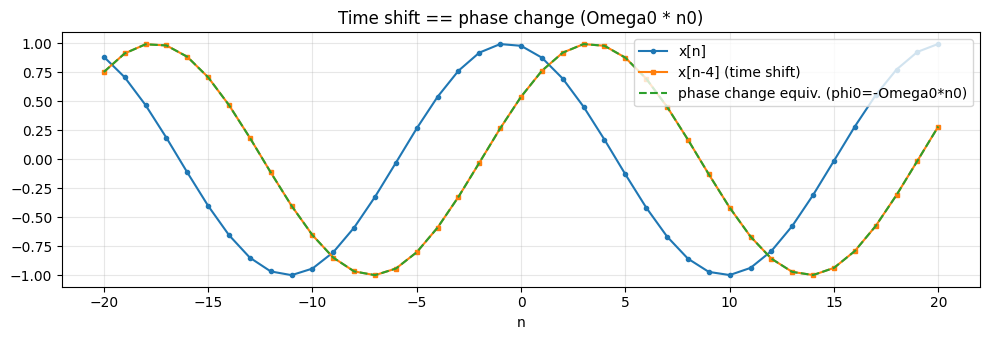

In [11]:
n5 = np.arange(-20, 21)
A, Omega0, phi = 1.0, 0.3, 0.2
n0 = 4

x_orig = sinusoid(n5, A, Omega0, phi)
x_shift = time_shift_sinusoid(n5, A, Omega0, phi, n0)
x_phase = phase_change_sinusoid(n5, A, Omega0, phi, -Omega0 * n0)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(n5, x_orig, label="x[n]", marker='o', markersize=3)
ax.plot(n5, x_shift, label=f"x[n-{n0}] (time shift)", marker='s', markersize=3)
ax.plot(n5, x_phase, label="phase change equiv. (phi0=-Omega0*n0)", linestyle='--')
ax.set_title("Time shift == phase change (Omega0 * n0)")
ax.set_xlabel("n")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Question Set 6 — Energy, Power, and System Outputs

In [12]:
def energy(x):
    x = np.asarray(x, dtype=float)
    return np.sum(np.abs(x) ** 2)

def average_power(x):
    x = np.asarray(x, dtype=float)
    return energy(x) / len(x)

def sys_diff(x):
    """y[n] = x[n] - x[n-1]"""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    y[1:] = x[1:] - x[:-1]
    return y

def sys_n_times_x(x):
    """y[n] = n * x[n]"""
    x = np.asarray(x, dtype=float)
    return N * x

def sys_square(x):
    """y[n] = x[n]^2"""
    x = np.asarray(x, dtype=float)
    return x ** 2

def sys_add5(x):
    """y[n] = x[n] + 5"""
    x = np.asarray(x, dtype=float)
    return x + 5

def sys_centered_avg(x):
    """y[n] = 0.5*(x[n-1] + x[n] + x[n+1])"""
    x = np.asarray(x, dtype=float)
    xm1 = np.zeros_like(x); xm1[1:] = x[:-1]
    xp1 = np.zeros_like(x); xp1[:-1] = x[1:]
    return 0.5 * (xm1 + x + xp1)

def sys_reverse(x):
    """y[n] = x[-n]"""
    x = np.asarray(x, dtype=float)
    return x[::-1]


Energy: 6.5
Average power: 0.38235294117647056


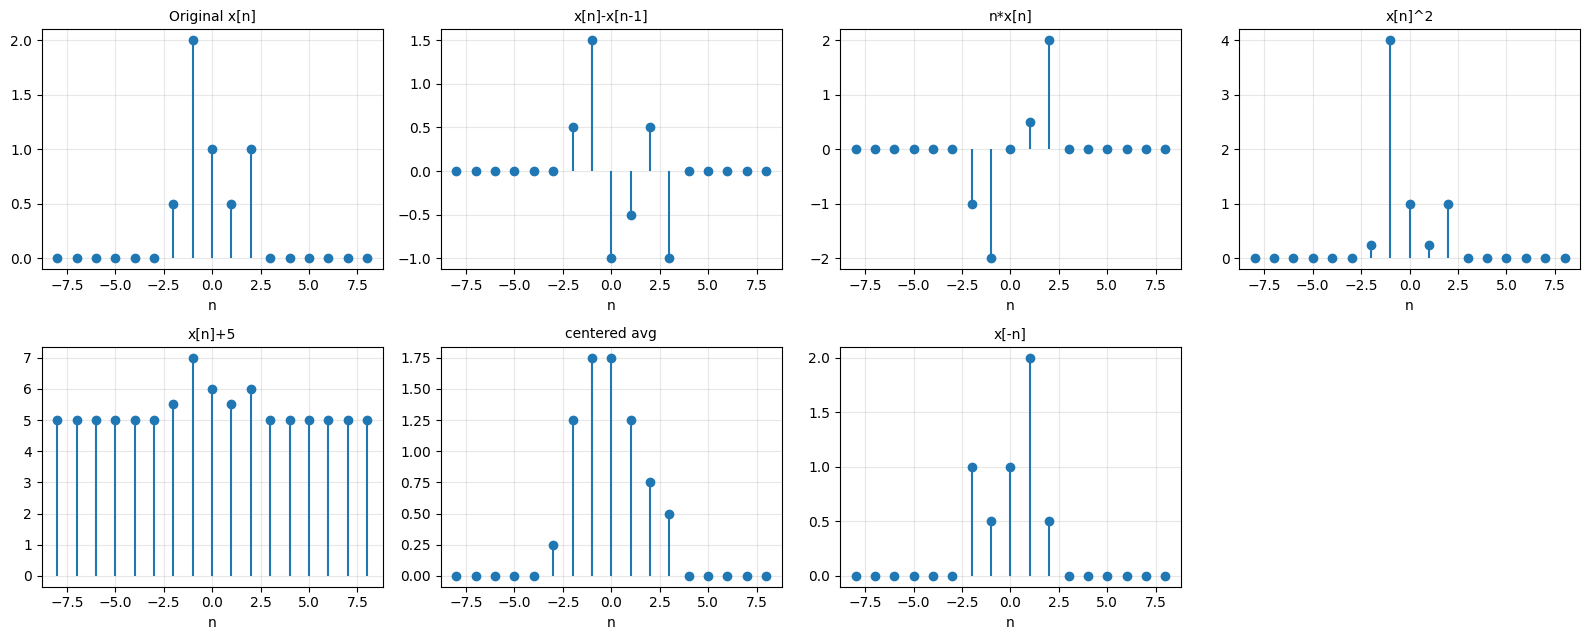

In [13]:
print("Energy:", energy(x))
print("Average power:", average_power(x))

systems = {
    "x[n]-x[n-1]": sys_diff,
    "n*x[n]": sys_n_times_x,
    "x[n]^2": sys_square,
    "x[n]+5": sys_add5,
    "centered avg": sys_centered_avg,
    "x[-n]": sys_reverse,
}

fig, axs = plt.subplots(2, 4, figsize=(16, 6.5))
axs = axs.ravel()
stem_plot(axs[0], N, x, "Original x[n]")
for i, (name, fn) in enumerate(systems.items(), start=1):
    stem_plot(axs[i], N, fn(x), name)
for j in range(len(systems) + 1, len(axs)):
    axs[j].axis("off")
plt.tight_layout()
plt.show()
